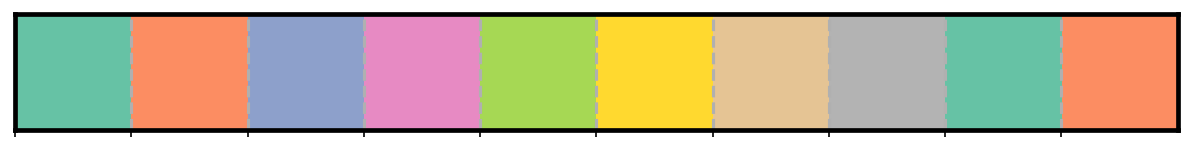

In [71]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
import pandas as pd
from iminuit import Minuit
from scipy import stats
from iminuit import cost
from scipy import integrate
import scipy
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.model_selection import RandomizedSearchCV


def setup_plotting(ticksize=14, fontsize=20, figsize=(16, 9), dpi=150):
    """
    Global plotting setup with grey background and custom styling
    """

    # --- Figure defaults ---
    plt.rcParams.update({
        "figure.figsize": figsize,
        "figure.dpi": dpi,
    })

    # --- Background color ---
    plt.rcParams['axes.facecolor'] = "#e8e8e8"

    # --- Fonts ---
    rc = {"font.family": "serif", 
          "mathtext.fontset": "stix"}
    plt.rcParams.update(rc)
    plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
    
    plt.rcParams.update({
        "font.size": fontsize,
        "xtick.labelsize": ticksize,
        "ytick.labelsize": ticksize,
    })

    # --- Axes & ticks ---
    plt.rcParams.update({
        "axes.linewidth": 2.25,
        "axes.formatter.limits": (-1, 3),
        "axes.grid": True,
        "legend.facecolor": "white",
    })

    # --- Grid ---
    plt.rcParams.update({
        "grid.linestyle": "--",
        "grid.linewidth": 1.5,
    })

    # --- Color palette ---
    colors = sns.color_palette("Set2", 10)
    sns.set_palette(colors)
    sns.palplot(colors)
    plt.show()

    return colors




def stylize_ticks(fig, ax):
    """
    Apply inward ticks, minor ticks, and label offsets
    """

    ax.xaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, top=True)
    ax.yaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, right=True)

    ax.xaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, top=True)
    ax.yaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, right=True)

    # Label offsets
    dx = -3 / 72
    dy = -3 / 72
    x_offset = matplotlib.transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)
    y_offset = matplotlib.transforms.ScaledTranslation(0, dy, fig.dpi_scale_trans)

    for label in ax.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + y_offset)

    for label in ax.yaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + x_offset)
colors = setup_plotting(ticksize=18, fontsize=30, figsize=(16, 9), dpi=150)

In [72]:
bg_01 = stats.poisson.rvs(mu=0.2, size=100)
bg_10 = stats.poisson.rvs(mu=10, size=100)
bg_1000 = stats.poisson.rvs(mu=1000, size=100)

signal_1 = stats.poisson.rvs(mu=1000, size=100)
signal_1[0] = signal_1[0] + stats.poisson.rvs(mu=100, size=1)[0]

signal_2 = stats.poisson.rvs(mu=1000, size=100)
signal_2[0] = signal_2[0] + stats.poisson.rvs(mu=200, size=1)[0]

In [73]:
def lambda_func(x, Nbins):
    x1 = x[0]
    Ntot = np.sum(x)
    if x1 == 0 or x1 == Ntot:
        x1 += 1e-5
    if Ntot - x1 == 0:
        Ntot -= 1e-5
        
    return 2* x1 * np.log(Nbins *x1 / Ntot) + 2*(Ntot - x1)* np.log((Nbins/Ntot) * (Ntot-x1) /((Nbins -1)))

In [74]:
bg_01_vals = []
bg_10_vals = []
bg_1000_vals = []

signal_1_vals = []
signal_2_vals = []

for i in range(int(1e5)):
    bg_01 = stats.poisson.rvs(mu=0.2, size=100)
    bg_10 = stats.poisson.rvs(mu=10, size=100)
    bg_1000 = stats.poisson.rvs(mu=1000, size=100)

    signal_1 = stats.poisson.rvs(mu=1000, size=100)
    signal_1[0] = signal_1[0] + stats.poisson.rvs(mu=100, size=1)[0]

    signal_2 = stats.poisson.rvs(mu=1000, size=100)
    signal_2[0] = signal_2[0] + stats.poisson.rvs(mu=200, size=1)[0]
    bg_01_vals.append(lambda_func(bg_01, 100))
    bg_10_vals.append(lambda_func(bg_10, 100))
    bg_1000_vals.append(lambda_func(bg_1000, 100))
    signal_1_vals.append(lambda_func(signal_1, 100))
    signal_2_vals.append(lambda_func(signal_2, 100))

In [75]:
bg_10_vals

[np.float64(0.0571408149207413),
 np.float64(0.05523984577762042),
 np.float64(1.9267054464157383),
 np.float64(3.134120853965313),
 np.float64(0.0006499509028091432),
 np.float64(0.037432964770010235),
 np.float64(3.064411614633226),
 np.float64(0.6923622171835797),
 np.float64(1.0277635684757556),
 np.float64(1.1009454160605312),
 np.float64(0.4541234471905313),
 np.float64(0.0032337841173580295),
 np.float64(0.6133725963076042),
 np.float64(5.382339053822934),
 np.float64(1.4583158155908675),
 np.float64(0.09465237373979685),
 np.float64(0.6647059146468841),
 np.float64(0.02304168113802152),
 np.float64(0.2758618831583628),
 np.float64(0.3200582006314261),
 np.float64(4.249188842082379),
 np.float64(3.174662917259793),
 np.float64(1.95113288848089),
 np.float64(1.2228414602462463),
 np.float64(0.1065487373005205),
 np.float64(0.0003651048992418249),
 np.float64(0.662416090859355),
 np.float64(2.219765533251506),
 np.float64(1.28330991206135),
 np.float64(1.0035578766015627),
 np.flo

Text(0, 0.5, 'Counts')

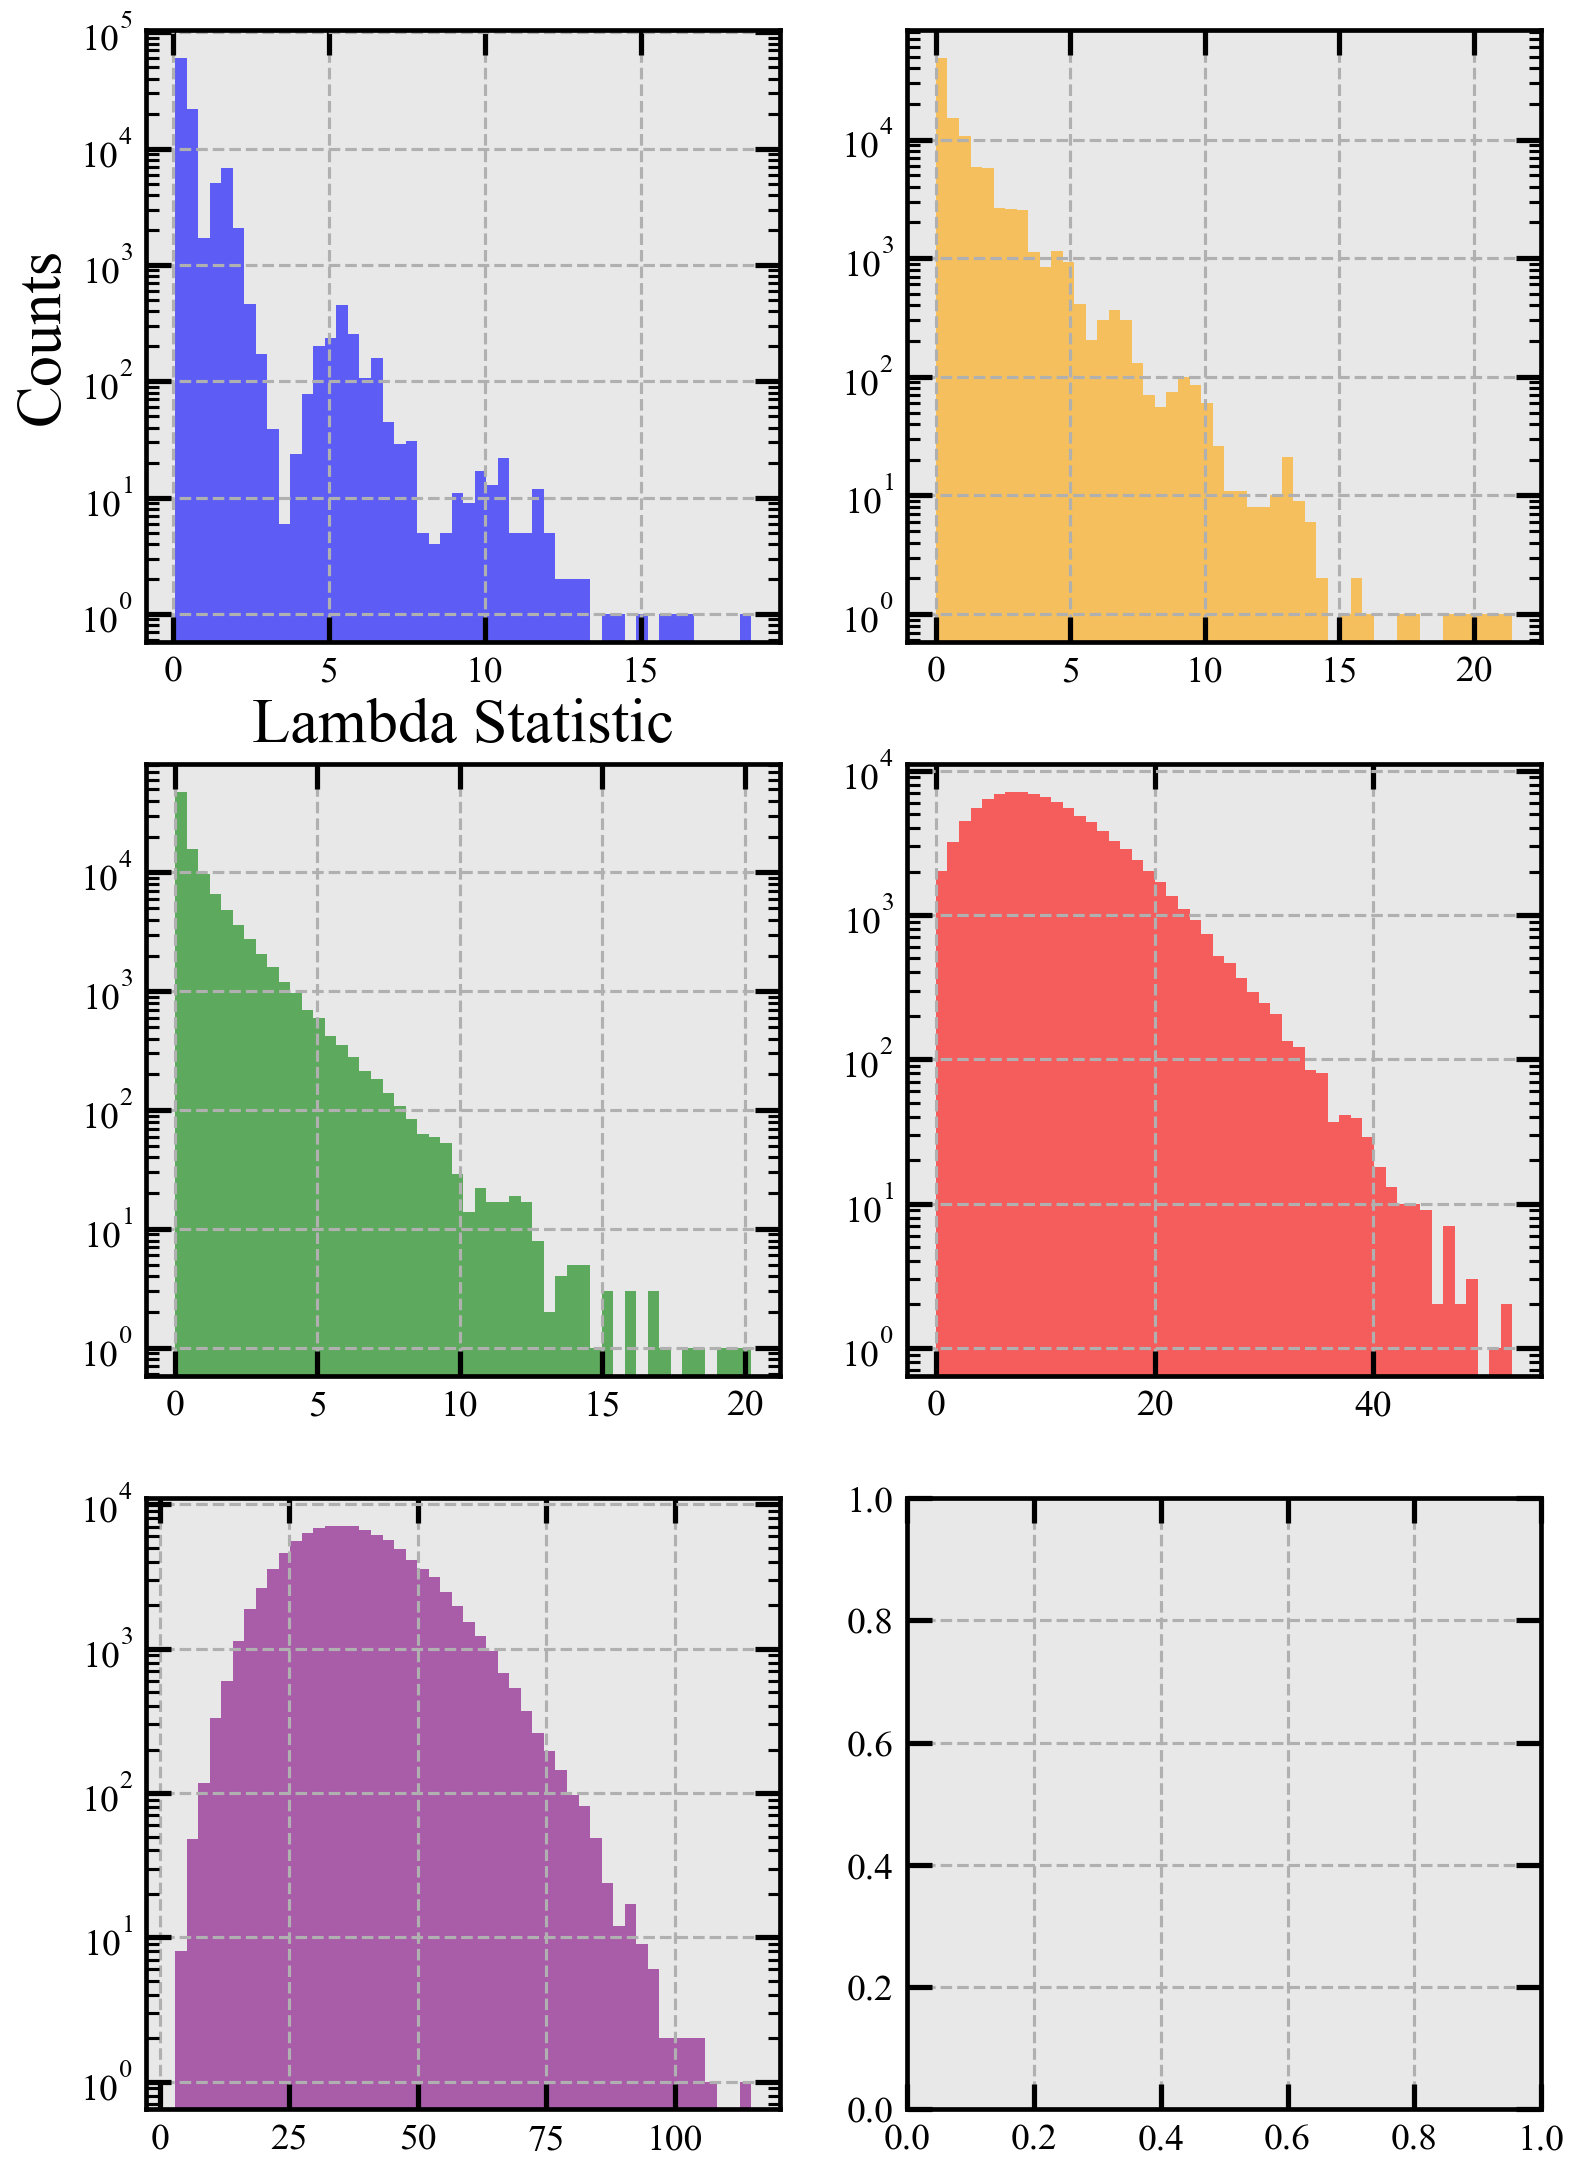

In [76]:
Nbins = 50
fig, ax = plt.subplots(3,2, figsize=(12, 18))
ax[0,0].hist(bg_01_vals, bins=Nbins, alpha=0.6, color='blue', label='Background (mu=0.2)', density=False)
ax[0,1].hist(bg_10_vals, bins=Nbins, alpha=0.6, color='orange', label='Background (mu=10)', density=False)
ax[1,0].hist(bg_1000_vals, bins=Nbins, alpha=0.6, color='green', label='Background (mu=1000)', density=False)
ax[1,1].hist(signal_1_vals, bins=Nbins, alpha=0.6, color='red', label='Signal 1 (mu=1000 + 100)', density=False)
ax[2,0].hist(signal_2_vals, bins=Nbins, alpha=0.6, color='purple', label='Signal 2 (mu=1000 + 200)', density=False)
stylize_ticks(fig, ax[0,0])
stylize_ticks(fig, ax[0,1])
stylize_ticks(fig, ax[1,0])
stylize_ticks(fig, ax[1,1])
stylize_ticks(fig, ax[2,0])
stylize_ticks(fig, ax[2,1])
ax[0,0].set_yscale('log')
ax[0,1].set_yscale('log')
ax[1,0].set_yscale('log')
ax[1,1].set_yscale('log')
ax[2,0].set_yscale('log')

ax[0,0].set_xlabel('Lambda Statistic')
ax[0,0].set_ylabel('Counts')
